# B3 — Model-Based Private→Public Standardization

**This is a standardized prediction scenario, not a causal effect and not a
counterfactual treatment effect.** Every summary number below describes what
the already-fitted, already-validated XGBoost model *predicts* would change
if `facility_type` were set to `public` on an observed private-sector
record, holding every other observed input fixed. It does not estimate what
would actually happen if that woman had been moved to a public facility —
that requires the assumptions B4 (AIPW) makes explicit, which have not been
invoked here. Every output file, table, and figure name in this notebook is
deliberately labeled `standardization`, never `effect` or `counterfactual`.

**Not run here.** Written but not executed, per instruction — no commands
were run, no model fit, no bootstrap performed while authoring this
notebook. Run it locally in VS Code.

**Model-artifact policy (same as the SHAP notebook):** checks for a saved
pipeline at `outputs/models/b2_xgboost_pipeline.joblib`; if absent,
deterministically refits the identical B2 pipeline and validates it against
`b2_model_performance.csv` before using it here.

**Common-support policy, stated plainly because no formal propensity model
exists yet in this project sequence:** the frozen protocol's formal
overlap/propensity diagnostics (DAG-approved confounder set, fitted
propensity model, trimming rule) belong to the B4 preparation step, which
has not been run. Rather than invent a causal propensity model here, this
notebook uses a **descriptive, non-causal common-support check**: private
test records are cross-tabulated against public test records within cells
defined by `risk_stratum_primary` × `wealth_index` × `residence`, and a
private record is treated as having adequate common support only if its
cell contains at least `MIN_CELL_N` public comparators. This is a
practical, transparent stand-in — not a substitute for the formal B4
overlap analysis, and this notebook says so again at the point it's used.

## 1. Imports, paths, constants

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

V2_PATH = Path("../../data/processed/df_model_v2.parquet")
MODEL_ARTIFACT_PATH = Path("../../outputs/models/b2_xgboost_pipeline.joblib")
B2_PERFORMANCE_PATH = Path("../../outputs/tables/b2_model_performance.csv")

OUTPUTS_DIR = Path("../../outputs")
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"
METADATA_DIR = OUTPUTS_DIR / "metadata"
for d in (TABLES_DIR, FIGURES_DIR, METADATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
MIN_CELL_N = 30          # minimum public comparators required in a cell for common support
N_BOOTSTRAP = 500        # PSU-cluster bootstrap replicates
BOOTSTRAP_SEED = 42      # separate, explicit seed for the bootstrap RNG

## 2. Load `df_model_v2` (read-only) and re-assert dataset integrity

In [2]:
df = pd.read_parquet(V2_PATH)  # read-only
n_loaded = len(df)

EXPECTED_ROW_COUNT = 201311
assert n_loaded == EXPECTED_ROW_COUNT, (
    f"df_model_v2 row count is {n_loaded}, expected {EXPECTED_ROW_COUNT}. Stop and investigate."
)
print(f"Loaded shape: {df.shape} -- matches the frozen Step 2 value.")

Loaded shape: (201311, 53) -- matches the frozen Step 2 value.


## 3. Rebuild the approved predictor set, split, and pipeline (identical to B2)

Duplicated deliberately so this notebook is self-contained and reproducible
on its own.

In [3]:
numeric_features = [
    "maternal_age", "education_years", "wealth_index", "birth_order",
    "total_children_ever_born", "preceding_birth_interval", "age_at_first_birth",
    "bmi", "first_anc_timing", "anc_visits",
]
categorical_features = ["facility_type", "residence", "religion", "social_group", "twin_order"]
binary_features = [
    "health_insurance", "anc_doctor", "anc_nurse_midwife", "anc_traditional_attendant",
    "anc_community_worker", "anc_anganwadi_worker", "anc_asha_worker", "anc_other_provider",
    "no_anc_provider", "weight_measured_during_pregnancy", "bp_measured_during_pregnancy",
    "urine_sample_during_pregnancy", "blood_sample_during_pregnancy",
    "told_about_pregnancy_complications", "counselled_vaginal_bleeding", "counselled_convulsions",
    "counselled_prolonged_labour", "counselled_severe_abdominal_pain", "counselled_high_blood_pressure",
    "convulsions_during_pregnancy", "swelling_during_pregnancy",
]
feature_cols = numeric_features + categorical_features + binary_features
assert len(feature_cols) == 36

forbidden_columns = {
    "respondent_id", "birth_index", "cluster_number", "household_number", "respondent_line_number",
    "sample_weight", "sample_weight_normalized", "primary_sampling_unit",
    "sample_stratum_v022", "sample_stratum_v023", "state", "district",
    "csection", "delivery_place_code",
    "risk_stratum_primary", "risk_stratum_refined_sensitivity", "first_birth",
}
assert forbidden_columns.isdisjoint(set(feature_cols)), "Forbidden column found in predictor set."

X = df[feature_cols].copy()
for col in categorical_features + binary_features:
    X[col] = X[col].astype("string").fillna("Missing").astype(str)
assert len(X) == n_loaded

y = df["csection"].astype(int)
groups = df["respondent_id"].copy()

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
groups_train, groups_test = groups.iloc[train_idx].copy(), groups.iloc[test_idx].copy()

overlap_respondents = set(groups_train) & set(groups_test)
assert not overlap_respondents, f"Respondent leakage detected: {len(overlap_respondents)}"
print(f"Train: {X_train.shape} | Test: {X_test.shape} | Respondent overlap: {len(overlap_respondents)} (confirmed zero)")

Train: (161048, 36) | Test: (40263, 36) | Respondent overlap: 0 (confirmed zero)


## 4. Load the saved model if available, otherwise refit deterministically, then validate

In [4]:
tree_preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median", add_indicator=True), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features + binary_features),
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = dict(
    objective="binary:logistic", eval_metric="logloss", scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
    colsample_bytree=0.7141915784487018, gamma=0.6084844859190754,
    learning_rate=0.048164145309070844, max_depth=6, min_child_weight=9,
    n_estimators=198, reg_alpha=0.012563152773938664, reg_lambda=0.6305535040199283,
    subsample=0.6663329821247654,
)  # reused from v1 05_hyperparameter_tuning.ipynb, same as B2 and the SHAP notebook

if MODEL_ARTIFACT_PATH.exists():
    xgb_pipeline = joblib.load(MODEL_ARTIFACT_PATH)
    model_source = f"loaded from {MODEL_ARTIFACT_PATH}"
else:
    xgb_pipeline = Pipeline([("pre", tree_preprocessor), ("clf", XGBClassifier(**xgb_params))])
    xgb_pipeline.fit(X_train, y_train)  # fit on TRAINING data only -- never on test
    model_source = "refit in this notebook (no saved artifact found)"

print("Model source:", model_source)

# Consistency check against B2's saved performance, same pattern as the SHAP notebook.
fresh_test_proba = xgb_pipeline.predict_proba(X_test)[:, 1]
fresh_roc_auc = roc_auc_score(y_test, fresh_test_proba)
fresh_pr_auc = average_precision_score(y_test, fresh_test_proba)
TOLERANCE = 0.005
if B2_PERFORMANCE_PATH.exists():
    b2_perf = pd.read_csv(B2_PERFORMANCE_PATH)
    b2_xgb = b2_perf[b2_perf["model"] == "XGBoost"]
    if len(b2_xgb) == 1:
        diff_roc = abs(fresh_roc_auc - float(b2_xgb["roc_auc"].iloc[0]))
        diff_pr = abs(fresh_pr_auc - float(b2_xgb["pr_auc"].iloc[0]))
        if diff_roc > TOLERANCE or diff_pr > TOLERANCE:
            print(f"WARNING: model diverges from B2's recorded performance (ROC-AUC diff {diff_roc:.4f}, "
                  f"PR-AUC diff {diff_pr:.4f}) -- investigate before trusting B3 results.")
        else:
            print(f"Consistent with B2's recorded performance (ROC-AUC diff {diff_roc:.4f}, PR-AUC diff {diff_pr:.4f}).")
    else:
        print("WARNING: could not find a single XGBoost row in b2_model_performance.csv -- skipping check.")
else:
    print(f"WARNING: {B2_PERFORMANCE_PATH} not found -- cannot cross-check against B2.")

Model source: refit in this notebook (no saved artifact found)
Consistent with B2's recorded performance (ROC-AUC diff 0.0000, PR-AUC diff 0.0000).


## 5. Assemble the locked-test analysis frame

Pulls in the survey/design/stratum columns needed for weighting, common
support, and stratified reporting, aligned to `X_test` by index. No new
filtering is applied here beyond what the split already did.

In [5]:
test_context_cols = [
    "respondent_id", "facility_type", "risk_stratum_primary", "wealth_index", "residence",
    "cluster_number", "sample_stratum_v022", "sample_weight_normalized",
]
test_context = df.loc[X_test.index, test_context_cols].copy()

assert test_context.index.equals(X_test.index), "Context frame is not aligned to X_test."
print(f"Test context frame: {test_context.shape}")
print(test_context["facility_type"].value_counts())

Test context frame: (40263, 8)
facility_type
public     29968
private    10202
other         93
Name: count, dtype: int64


## 6. Common-support diagnostic (descriptive, non-causal)

Cross-tabulates private vs public test records within
`risk_stratum_primary` × `wealth_index` × `residence` cells. A private
record has adequate common support only if its cell contains at least
`MIN_CELL_N` public comparators. This is a practical stand-in, explicitly
not the formal DAG-based propensity/overlap analysis the frozen protocol
assigns to B4 preparation.

In [6]:
cell_cols = ["risk_stratum_primary", "wealth_index", "residence"]

cell_counts = (
    test_context
    .groupby(cell_cols + ["facility_type"])
    .size()
    .unstack("facility_type", fill_value=0)
    .reset_index()
)
for col in ["public", "private", "other"]:
    if col not in cell_counts.columns:
        cell_counts[col] = 0

cell_counts["adequate_common_support"] = cell_counts["public"] >= MIN_CELL_N
cell_counts.to_csv(TABLES_DIR / "b3_common_support_diagnostics.csv", index=False)

n_cells = len(cell_counts)
n_inadequate = (~cell_counts["adequate_common_support"]).sum()
print(f"Cells defined: {n_cells} | Cells with < {MIN_CELL_N} public comparators: {n_inadequate}")

# Tag each private test record with its cell's common-support status.
test_context = test_context.merge(
    cell_counts[cell_cols + ["adequate_common_support"]], on=cell_cols, how="left",
)
test_context.index = X_test.index  # merge resets the index -- restore alignment to X_test
assert test_context.index.equals(X_test.index), "Lost alignment to X_test after merging common-support flags."

private_mask = test_context["facility_type"] == "private"
n_private_total = int(private_mask.sum())
n_private_common_support = int((private_mask & test_context["adequate_common_support"]).sum())
print(f"Private test records: {n_private_total}")
print(f"Private test records with adequate common support: {n_private_common_support} "
      f"({n_private_common_support / n_private_total * 100:.2f}%)")

Cells defined: 30 | Cells with < 30 public comparators: 5
Private test records: 10202
Private test records with adequate common support: 10122 (99.22%)


## 7. Observed-private predictions

Only locked-test private-sector records enter this scenario — asserted
explicitly, not assumed.

In [7]:
private_index = test_context.index[private_mask]

assert set(private_index).issubset(set(X_test.index)), "Private scenario includes non-test records."
assert (test_context.loc[private_index, "facility_type"] == "private").all(), \
    "Non-private record found in the observed-private scenario."

X_private_observed = X_test.loc[private_index].copy()
p_private = xgb_pipeline.predict_proba(X_private_observed)[:, 1]

print(f"Observed-private predictions computed for {len(X_private_observed)} records.")

Observed-private predictions computed for 10202 records.


## 8. Public-set copies — change only `facility_type`

Deep-copies the same private records and flips `facility_type` to
`"public"`; every other column is asserted unchanged, row order and count
are asserted unchanged, and the same fitted pipeline object is reused for
prediction.

In [8]:
X_public_set = X_private_observed.copy(deep=True)
X_public_set["facility_type"] = "public"

# --- Assertions: only facility_type changed; row order/count unchanged ---
assert X_public_set.shape == X_private_observed.shape, "Row count/shape changed between scenarios."
assert X_public_set.index.equals(X_private_observed.index), "Row order changed between scenarios."

other_cols = [c for c in feature_cols if c != "facility_type"]
# Use DataFrame.equals(), not elementwise `==`, because several numeric columns
# carry pandas nullable NA (e.g. bmi, anc_visits, preceding_birth_interval).
# Elementwise `==` returns NA (not True/False) when comparing NA to NA, which
# makes `.all()` raise -- .equals() correctly treats matching NA positions as equal.
assert X_public_set[other_cols].equals(X_private_observed[other_cols]), \
    "A column other than facility_type differs between the two scenarios."
assert (X_public_set["facility_type"] == "public").all()
assert (X_private_observed["facility_type"] == "private").all()

print("Confirmed: only facility_type differs between the observed-private and public-set frames.")

# Same fitted pipeline object used for both scenarios -- no retraining on test data anywhere here.
p_public_set = xgb_pipeline.predict_proba(X_public_set)[:, 1]
print(f"Public-set predictions computed for {len(X_public_set)} records using the identical fitted pipeline.")

Confirmed: only facility_type differs between the observed-private and public-set frames.
Public-set predictions computed for 10202 records using the identical fitted pipeline.


## 9. Assemble the record-level B3 result and save

In [9]:
b3_records = test_context.loc[private_index, [
    "respondent_id", "facility_type", "risk_stratum_primary", "wealth_index", "residence",
    "cluster_number", "sample_stratum_v022", "sample_weight_normalized", "adequate_common_support",
]].copy()
b3_records["p_private_observed"] = p_private
b3_records["p_public_set"] = p_public_set
b3_records["delta"] = b3_records["p_private_observed"] - b3_records["p_public_set"]

assert len(b3_records) == n_private_total
b3_records.to_csv(TABLES_DIR / "b3_record_level_standardization.csv", index=False)
print(f"Saved record-level file: {len(b3_records)} rows.")
b3_records.head()

Saved record-level file: 10202 rows.


,respondent_id,facility_type,risk_stratum_primary,wealth_index,residence,cluster_number,sample_stratum_v022,sample_weight_normalized,adequate_common_support,p_private_observed,p_public_set,delta
93,0100102243 04,private,lower_risk,5,2,122,122,0.333770,True,0.770229,0.607387,0.162843
221,0100101905 03,private,lower_risk,4,2,119,123,0.230664,True,0.866949,0.776715,0.090234
222,0100101905 05,private,lower_risk,4,2,119,123,0.230664,True,0.827843,0.702164,0.125679
276,0100102694 02,private,not_applicable_multiparous,2,1,126,11,0.349898,True,0.893174,0.830744,0.062429
738,0100503331 04,private,not_applicable_multiparous,5,2,533,522,0.225936,True,0.723624,0.556675,0.166948


## 10. Survey-weighted summary statistics (point estimates)

Weighted mean, weighted median, and weighted quantiles use
`sample_weight_normalized`. Primary reporting restricts to records with
adequate common support; the all-private (unrestricted) figures are also
reported for transparency, clearly labeled as such.

In [10]:
def weighted_mean(values, weights):
    return np.average(values, weights=weights)


def weighted_quantile(values, weights, quantiles):
    """Weighted quantiles via linear interpolation on the weighted empirical CDF
    (Hazen-type definition)."""
    values = np.asarray(values)
    weights = np.asarray(weights)
    sorter = np.argsort(values)
    values, weights = values[sorter], weights[sorter]
    cum_weights = np.cumsum(weights) - 0.5 * weights
    cum_weights /= np.sum(weights)
    return np.interp(quantiles, cum_weights, values)


def summarize_group(data, label):
    w = data["sample_weight_normalized"].to_numpy()
    delta = data["delta"].to_numpy()
    p_priv = data["p_private_observed"].to_numpy()
    p_pub = data["p_public_set"].to_numpy()
    q = weighted_quantile(delta, w, [0.05, 0.25, 0.5, 0.75, 0.95])
    return {
        "label": label,
        "n": len(data),
        "mean_delta_pct": weighted_mean(delta, w) * 100,
        "median_delta_pct": q[2] * 100,
        "p05_delta_pct": q[0] * 100,
        "p25_delta_pct": q[1] * 100,
        "p75_delta_pct": q[3] * 100,
        "p95_delta_pct": q[4] * 100,
        "mean_p_private_observed_pct": weighted_mean(p_priv, w) * 100,
        "mean_p_public_set_pct": weighted_mean(p_pub, w) * 100,
    }


common_support_records = b3_records[b3_records["adequate_common_support"]]

overall_rows = [
    summarize_group(b3_records, "overall_all_private_unrestricted"),
    summarize_group(common_support_records, "overall_common_support_PRIMARY"),
]
for stratum in ["lower_risk", "elevated_risk"]:
    stratum_common_support = common_support_records[common_support_records["risk_stratum_primary"] == stratum]
    overall_rows.append(summarize_group(stratum_common_support, f"{stratum}_common_support_PRIMARY"))

point_estimates = pd.DataFrame(overall_rows)
point_estimates

,label,n,mean_delta_pct,median_delta_pct,p05_delta_pct,p25_delta_pct,p75_delta_pct,p95_delta_pct,mean_p_private_observed_pct,mean_p_public_set_pct
0,overall_all_private_unrestricted,10202,26.953228,26.758192,9.018517,17.868120,35.984880,45.699127,73.528524,46.575296
1,overall_common_support_PRIMARY,10122,27.053652,26.796582,9.173155,17.959261,36.039583,45.718079,73.410664,46.357012
2,lower_risk_common_support_PRIMARY,4604,26.874300,26.734584,9.093733,17.823570,36.064616,45.211756,76.154634,49.280334
3,elevated_risk_common_support_PRIMARY,162,15.232785,13.410277,6.260011,8.998880,18.213137,37.359431,88.231687,72.998902


## 11. PSU-cluster bootstrap for confidence intervals

Resamples PSUs (`cluster_number`) **with replacement, within strata**
(`sample_stratum_v022`) — the standard cluster-bootstrap approach for
complex survey designs — recomputes the weighted mean delta (and mean
`p_private`/`p_public_set`) on each resample, and takes the 2.5th/97.5th
percentiles across replicates as the 95% CI. Method, seed, and replicate
count are recorded in the metadata file, not just in this markdown cell.

In [11]:
def resample_indices_within_strata(psu_ids, stratum_ids, rng):
    """One PSU-cluster bootstrap resample: for each stratum, draw as many PSUs
    (with replacement) as were originally present, and return the row positions
    belonging to the drawn PSUs (with repeats for repeated PSU draws)."""
    row_positions = np.arange(len(psu_ids))
    out = []
    for stratum in np.unique(stratum_ids):
        stratum_mask = stratum_ids == stratum
        psus_in_stratum = np.unique(psu_ids[stratum_mask])
        n_psu = len(psus_in_stratum)
        drawn_psus = rng.choice(psus_in_stratum, size=n_psu, replace=True)
        for psu in drawn_psus:
            out.append(row_positions[stratum_mask & (psu_ids == psu)])
    return np.concatenate(out)


def bootstrap_group(data, n_reps, seed):
    values = data["delta"].to_numpy()
    p_priv = data["p_private_observed"].to_numpy()
    p_pub = data["p_public_set"].to_numpy()
    weights = data["sample_weight_normalized"].to_numpy()
    psu_ids = data["cluster_number"].to_numpy()
    stratum_ids = data["sample_stratum_v022"].to_numpy()

    rng = np.random.RandomState(seed)
    mean_delta_reps, mean_p_priv_reps, mean_p_pub_reps = [], [], []
    for _ in range(n_reps):
        idx = resample_indices_within_strata(psu_ids, stratum_ids, rng)
        w_r = weights[idx]
        mean_delta_reps.append(weighted_mean(values[idx], w_r))
        mean_p_priv_reps.append(weighted_mean(p_priv[idx], w_r))
        mean_p_pub_reps.append(weighted_mean(p_pub[idx], w_r))

    def ci(reps):
        return np.percentile(reps, 2.5), np.percentile(reps, 97.5)

    delta_ci = ci(mean_delta_reps)
    p_priv_ci = ci(mean_p_priv_reps)
    p_pub_ci = ci(mean_p_pub_reps)
    return {
        "mean_delta_ci_low_pct": delta_ci[0] * 100, "mean_delta_ci_high_pct": delta_ci[1] * 100,
        "mean_p_private_ci_low_pct": p_priv_ci[0] * 100, "mean_p_private_ci_high_pct": p_priv_ci[1] * 100,
        "mean_p_public_set_ci_low_pct": p_pub_ci[0] * 100, "mean_p_public_set_ci_high_pct": p_pub_ci[1] * 100,
    }


bootstrap_groups = {
    "overall_common_support_PRIMARY": common_support_records,
    "lower_risk_common_support_PRIMARY": common_support_records[common_support_records["risk_stratum_primary"] == "lower_risk"],
    "elevated_risk_common_support_PRIMARY": common_support_records[common_support_records["risk_stratum_primary"] == "elevated_risk"],
}

bootstrap_results = {}
for label, group_data in bootstrap_groups.items():
    print(f"Bootstrapping: {label} (n={len(group_data)}, {N_BOOTSTRAP} replicates)...")
    bootstrap_results[label] = bootstrap_group(group_data, N_BOOTSTRAP, BOOTSTRAP_SEED)

print("Bootstrap complete.")

Bootstrapping: overall_common_support_PRIMARY (n=10122, 500 replicates)...
Bootstrapping: lower_risk_common_support_PRIMARY (n=4604, 500 replicates)...
Bootstrapping: elevated_risk_common_support_PRIMARY (n=162, 500 replicates)...
Bootstrap complete.


## 12. Merge point estimates with bootstrap CIs and save final summary tables

In [12]:
point_estimates_indexed = point_estimates.set_index("label")

for label, ci_values in bootstrap_results.items():
    for key, value in ci_values.items():
        point_estimates_indexed.loc[label, key] = value

final_summary = point_estimates_indexed.reset_index()

overall_summary = final_summary[final_summary["label"].isin(
    ["overall_all_private_unrestricted", "overall_common_support_PRIMARY"]
)]
risk_stratified_summary = final_summary[final_summary["label"].isin(
    ["lower_risk_common_support_PRIMARY", "elevated_risk_common_support_PRIMARY"]
)]

overall_summary.to_csv(TABLES_DIR / "b3_overall_summary.csv", index=False)
risk_stratified_summary.to_csv(TABLES_DIR / "b3_risk_stratified_summary.csv", index=False)

print("Saved b3_overall_summary.csv and b3_risk_stratified_summary.csv")
final_summary

Saved b3_overall_summary.csv and b3_risk_stratified_summary.csv


,label,n,mean_delta_pct,median_delta_pct,p05_delta_pct,p25_delta_pct,p75_delta_pct,p95_delta_pct,mean_p_private_observed_pct,mean_p_public_set_pct,mean_delta_ci_low_pct,mean_delta_ci_high_pct,mean_p_private_ci_low_pct,mean_p_private_ci_high_pct,mean_p_public_set_ci_low_pct,mean_p_public_set_ci_high_pct
0,overall_all_private_unrestricted,10202,26.953228,26.758192,9.018517,17.868120,35.984880,45.699127,73.528524,46.575296,NaN,NaN,NaN,NaN,NaN,NaN
1,overall_common_support_PRIMARY,10122,27.053652,26.796582,9.173155,17.959261,36.039583,45.718079,73.410664,46.357012,26.801083,27.254032,73.079508,73.730629,45.889895,46.808240
2,lower_risk_common_support_PRIMARY,4604,26.874300,26.734584,9.093733,17.823570,36.064616,45.211756,76.154634,49.280334,26.593491,27.167094,75.921190,76.372011,48.784459,49.742572
3,elevated_risk_common_support_PRIMARY,162,15.232785,13.410277,6.260011,8.998880,18.213137,37.359431,88.231687,72.998902,14.769655,15.715444,87.835168,88.644386,72.312803,73.670667


## 13. Figures — delta distribution and forest-style summary

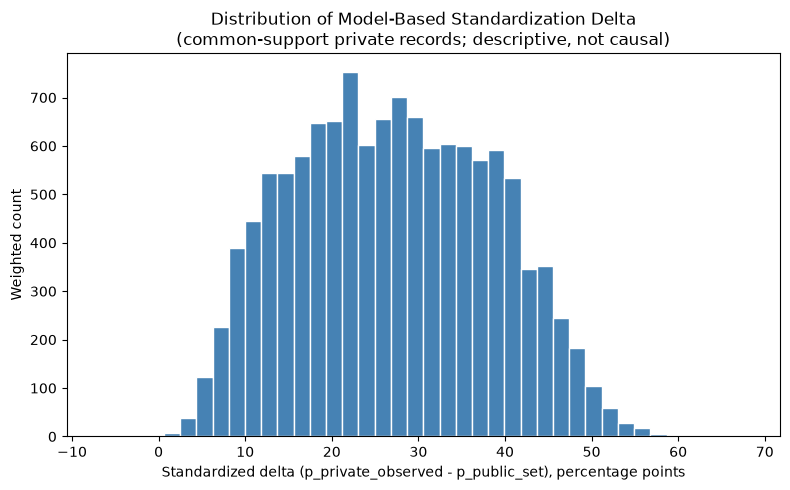

Saved: ..\..\outputs\figures\b3_delta_distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    common_support_records["delta"] * 100,
    bins=40,
    weights=common_support_records["sample_weight_normalized"],
    color="steelblue",
    edgecolor="white",
)
ax.set_xlabel("Standardized delta (p_private_observed - p_public_set), percentage points")
ax.set_ylabel("Weighted count")
ax.set_title("Distribution of Model-Based Standardization Delta\n(common-support private records; descriptive, not causal)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "b3_delta_distribution.png", dpi=200)
plt.show()
print("Saved:", FIGURES_DIR / "b3_delta_distribution.png")

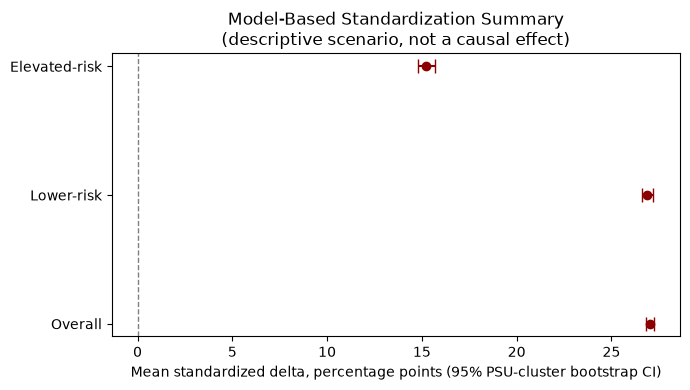

Saved: ..\..\outputs\figures\b3_forest_summary.png


In [14]:
forest_labels = ["Overall", "Lower-risk", "Elevated-risk"]
forest_rows = [
    final_summary[final_summary["label"] == "overall_common_support_PRIMARY"].iloc[0],
    final_summary[final_summary["label"] == "lower_risk_common_support_PRIMARY"].iloc[0],
    final_summary[final_summary["label"] == "elevated_risk_common_support_PRIMARY"].iloc[0],
]

means = [r["mean_delta_pct"] for r in forest_rows]
lows = [r["mean_delta_pct"] - r["mean_delta_ci_low_pct"] for r in forest_rows]
highs = [r["mean_delta_ci_high_pct"] - r["mean_delta_pct"] for r in forest_rows]

fig, ax = plt.subplots(figsize=(7, 4))
y_pos = np.arange(len(forest_labels))
ax.errorbar(means, y_pos, xerr=[lows, highs], fmt="o", capsize=5, color="darkred")
ax.set_yticks(y_pos)
ax.set_yticklabels(forest_labels)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Mean standardized delta, percentage points (95% PSU-cluster bootstrap CI)")
ax.set_title("Model-Based Standardization Summary\n(descriptive scenario, not a causal effect)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "b3_forest_summary.png", dpi=200)
plt.show()
print("Saved:", FIGURES_DIR / "b3_forest_summary.png")

## 14. Save metadata

In [15]:
metadata = {
    "random_state": RANDOM_STATE,
    "model_source": model_source,
    "common_support_rule": {
        "method": "descriptive cell-count check (NOT the formal B4 propensity/overlap analysis)",
        "cells_defined_by": cell_cols,
        "min_public_comparators_per_cell": MIN_CELL_N,
        "n_private_total": n_private_total,
        "n_private_common_support": n_private_common_support,
        "pct_private_common_support": round(n_private_common_support / n_private_total * 100, 2),
    },
    "bootstrap": {
        "method": "PSU-cluster bootstrap, resampled with replacement within sample_stratum_v022 strata",
        "n_replicates": N_BOOTSTRAP,
        "seed": BOOTSTRAP_SEED,
        "ci_method": "percentile (2.5 / 97.5)",
    },
    "interpretation_rule": (
        "All results are a model-based standardized prediction scenario. "
        "Never described as a causal effect or counterfactual treatment effect."
    ),
}

with open(METADATA_DIR / "b3_standardization_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved:", METADATA_DIR / "b3_standardization_metadata.json")

Saved: ..\..\outputs\metadata\b3_standardization_metadata.json
